In [1]:
import torch
import time
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scanpy as sc
import copy
from torch.utils.data import Dataset
from torch.utils.data import DataLoader


print("torch version:", torch.__version__)
print("cuda version:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("gpu count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))

torch version: 2.5.1
cuda version: 12.1
cuda available: True
gpu count: 1
gpu name: NVIDIA GeForce RTX 3070


In [2]:
class PromoterOneHotEncoder:
    def __init__(self, length=400):
        self.length = length
        self.vocab = {
            "A": 0,
            "C": 1,
            "G": 2,
            "T": 3,
            "N": 4
        }
        self.num_channels = 5

    def __call__(self, seq: str):
        """
        seq: str, length <= self.length
        return: FloatTensor (length, 5)
        """
        # 初始化为 N
        one_hot = torch.zeros(self.length, self.num_channels)
        one_hot[:, 4] = 1.0  # 默认 N

        seq = seq.upper()

        for i, base in enumerate(seq[:self.length]):
            idx = self.vocab.get(base, 4)
            one_hot[i, :] = 0.0
            one_hot[i, idx] = 1.0

        return one_hot

        
class CellBlockDataset(Dataset):
    def __init__(
        self,
        promoter_file,
        scrna_file,
        cell_ids_subset=None,
        promoters_per_block=None,
    ):
        self.promoters = pd.read_csv(promoter_file)
        self.scrna = sc.read(scrna_file, sparse=True)

        self.promoter_encoder = PromoterOneHotEncoder(length=400)
        print("Pre-encoding promoter sequences...")
        self.promoter_tensor = self._preencode_promoters()
        print("Done.")
        #self.gene_ids = gene_ids_subset
        self.use_direct_index = cell_ids_subset is None
        self.cells = cell_ids_subset or np.arange(self.scrna.n_obs)

        # 建 promoter index -> gene_id → scrna index 的映射
        self.gene2idx = {
            g: i for i, g in enumerate(self.scrna.var.gene_id)
        }
        self.promoter2expr_idx = np.empty(len(self.promoters), dtype=np.int32)
        for i, gene_id in enumerate(self.promoters["gene_id"]):
            try:
                self.promoter2expr_idx[i] = self.gene2idx[gene_id]
            except KeyError:
                raise ValueError(f"gene_id {gene_id} not found in scRNA var")
        #print(self.gene2idx)

        # block config
        self.P = len(self.promoters)
        self.C = len(self.cells)
        self.K = self.P if promoters_per_block is None else promoters_per_block

        self.num_blocks = int(np.ceil(self.P / self.K))

    def _preencode_promoters(self):
        sequences = self.promoters["sequence"].values
        n = len(sequences)

        # (N, 400, 5)
        promoter_tensor = torch.zeros(
            n, 400, 5, dtype=torch.float32
        )

        for i, seq in enumerate(sequences):
            promoter_tensor[i] = self.promoter_encoder(seq)

            if i % 1000 == 0:
                print(f"  encoded {i}/{n}")

        return promoter_tensor
    
    def __len__(self):
        return self.C * self.num_blocks

    def in_getitem(self, global_idx):
        pro_i = global_idx // self.C
        cell_i = global_idx % self.C
        promoter = self.promoter_tensor[pro_i]
        #gene_id = (self.promoters["gene_id"]).iloc[pro_i]
        if self.use_direct_index:
            expr_all = self.scrna[cell_i].X
        else:
            cell_id = self.cells[cell_i]
            expr_all = self.scrna[cell_id].X

        if hasattr(expr_all, "toarray"):
            expr_all = expr_all.toarray().astype("float32").squeeze()     # (16300,)
        expr_all = torch.from_numpy(expr_all).float()
        
        target_idx = self.promoter2expr_idx[pro_i]
        y = expr_all[target_idx]
        #expr_all[target_idx] = 0.0 # mask the promoter expression
        
        return promoter, expr_all, y

    def __getitem__(self, idx):
        cell_idx = idx // self.num_blocks
        block_idx = idx % self.num_blocks
        # ---- get promoter block ----
        start = block_idx * self.K
        end = min(start + self.K, self.P)

        promoter_block = self.promoter_tensor[start:end]  # (K, 400, 5)
        target_idxs = self.promoter2expr_idx[start:end]   # (K,)
        # ---- get expr for this cell (SPARSE) ----
        expr_sparse = self.scrna.X[cell_idx]
        expr_dense = expr_sparse.toarray().astype("float32").squeeze()
        y = expr_dense[target_idxs]
        return promoter_block, expr_dense, y
def move_block_to_gpu(batch, device):
    """
    batch: list of length B (B blocks)
    """
    promoter_blocks = []
    expr_blocks = []
    target_blocks = []

    for promoter_block, expr_dense, y in batch:
        promoter_blocks.append(promoter_block)
        ys.append(torch.from_numpy(y))
        expr_blocks.append(torch.from_numpy(expr_dense))

    promoter_blocks = torch.cat(promoter_blocks, dim=0).to(device)
    ys = torch.cat(ys).to(device)
    expr_blocks = torch.stack(expr_blocks).to(device)

    return promoter_blocks, expr_blocks, ys

train_dataset = CellBlockDataset(
    promoter_file="promoter_train.csv",
    scrna_file="integrated_data.h5ad",
    promoters_per_block=4077,
)
# val_dataset = MyDataset(
#     promoter_file="promoter_val.csv",
#     scrna_file="integrated_data.h5ad",
# )

Pre-encoding promoter sequences...
  encoded 0/16308
  encoded 1000/16308
  encoded 2000/16308
  encoded 3000/16308
  encoded 4000/16308
  encoded 5000/16308
  encoded 6000/16308
  encoded 7000/16308
  encoded 8000/16308
  encoded 9000/16308
  encoded 10000/16308
  encoded 11000/16308
  encoded 12000/16308
  encoded 13000/16308
  encoded 14000/16308
  encoded 15000/16308
  encoded 16000/16308
Done.


In [3]:
# model
class SimpleGeneModel(nn.Module):
    def __init__(self, promoter_len=400, promoter_channels=5, 
                 lstm_hidden=64, expr_dim=16262):
        super().__init__()
        # promoter LSTM
        self.lstm = nn.LSTM(input_size=promoter_channels, hidden_size=lstm_hidden,
                            batch_first=True)
        # expression MLP
        self.expr_fc = nn.Linear(expr_dim, lstm_hidden)
        # output
        self.fc_out = nn.Linear(2 * lstm_hidden, 1)
        self.relu = nn.ReLU()

    def forward(self, promoter, expr):
        # promoter: (batch, 400, 5)
        # expr: (batch, 16300)
        lstm_out, _ = self.lstm(promoter)        # (batch, 400, hidden)
        lstm_out = lstm_out[:, -1, :]            # take last time step -> (batch, hidden)
        expr_out = self.relu(self.expr_fc(expr)) # (batch, hidden)
        combined = torch.cat([lstm_out, expr_out], dim=1)  # (batch, 2*hidden)
        out = self.fc_out(combined)              # (batch, 1)
        return out

class SequentialGPUBatchSampler:
    def __init__(self, total_size, batch_size):
        self.total_size = total_size
        self.batch_size = batch_size
        self.cursor = 0

    def next(self):
        if self.cursor >= self.total_size:
            raise StopIteration

        start = self.cursor
        end = min(start + self.batch_size, self.total_size)
        self.cursor = end

        return slice(start, end)

    def reset(self):
        self.cursor = 0
def gpu_batch_seq(prom_buf, expr_buf, y_buf, sampler):
    sl = sampler.next()
    return (
        prom_buf[sl],
        expr_buf[sl],
        y_buf[sl],
    )

def make_dataloader(dataset, batch_size, shuffle, seed=42, num_workers=0):
    g = torch.Generator()
    g.manual_seed(seed)

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=True,
        generator=g if shuffle else None,
        drop_last=False,
    )
    return loader

@torch.no_grad
def ab_probe(model, promoters, exprs, ys, criterion):
    model.eval()
    promoters = promoters.to(device, non_blocking=True)
    exprs = exprs.to(device, non_blocking=True)
    ys = ys.to(device, non_blocking=True)
    
    # A: full
    out_full = model(promoters, exprs).squeeze(1)
    loss_full = criterion(out_full, ys).item()

    # B: no promoter
    promoters_zero = torch.zeros_like(promoters)
    out_nop = model(promoters_zero, exprs).squeeze(1)
    loss_nop = criterion(out_nop, ys).item()

    model.train()
    return loss_full, loss_nop

def evaluate(model, loader, mode, criterion, device, max_batches=100):
    """
    mode: "full" | "no_promoter" | "promoter_only"
    """
    model.eval() # transfer to validation mode, open dropout and set batch norm
    losses = []

    with torch.no_grad(): # turn off grad compute
        for i in range(max_batches):
            prom_buf, expr_buf, y_buf = fill_gpu_buffer(loader, device,1)
            sampler = SequentialGPUBatchSampler(
                total_size=prom_buf.size(0),
                batch_size=1024
            )
            while True:
                try:
                    promoters, exprs, ys = gpu_batch_seq(
                        prom_buf, expr_buf, y_buf, sampler
                    )
                except StopIteration:
                    break
                if mode == "no_promoter":
                    prom_buf = torch.zeros_like(prom_buf) # inherit the device of original tensor
                elif mode == "promoter_only":
                    expr_buf = torch.zeros_like(expr_buf)
                    
                out = model(prom_buf, expr_buf).squeeze(1)
                loss = criterion(out, y_buf)
                losses.append(loss.item())
            del prom_buf, expr_buf, y_buf
            torch.cuda.empty_cache()

    model.train()
    return sum(losses) / len(losses)

def fill_gpu_buffer(loader, device, n_batches):
    promoter_list = []
    expr_list = []
    y_list = []

    it = iter(loader)
    for _ in range(n_batches):
        promoter_block, expr_dense, y = next(it)
        # promoter_block: (B, K, 400, 5)
        # expr_dense:     (B, D)
        # y:              (B, K)

        B, K, L, C = promoter_block.shape
        D = expr_dense.shape[1]

        # ---- CPU 上 reshape ----
        promoter_block = promoter_block.view(B * K, L, C)   # (B*K, 400, 5)

        expr_block = (
            expr_dense
            .unsqueeze(1)          # (B, 1, D)
            .expand(B, K, D)       # (B, K, D)
            .reshape(B * K, D)     # (B*K, D)
        )

        y = y.view(B * K)          # (B*K,)

        promoter_list.append(promoter_block)
        expr_list.append(expr_block)
        y_list.append(y)

    # ---- CPU concat ----
    promoter_cpu = torch.cat(promoter_list, dim=0)
    expr_cpu = torch.cat(expr_list, dim=0)
    y_cpu = torch.cat(y_list, dim=0)

    # ---- 一次性搬到 GPU ----
    promoter_gpu = promoter_cpu.to(device, non_blocking=True)
    expr_gpu = expr_cpu.to(device, non_blocking=True)
    y_gpu = y_cpu.to(device, non_blocking=True)

    # print("promoter:", promoter_gpu.shape)
    # print("expr:", expr_gpu.shape)
    # print("y:", y_gpu.shape)

    return promoter_gpu, expr_gpu, y_gpu

def draw_oneblock(loader, n_batches):
    promoter_list = []
    expr_list = []
    y_list = []

    it = iter(loader)
    for _ in range(n_batches):
        promoter_block, expr_dense, y = next(it)
        # promoter_block: (B, K, 400, 5)
        # expr_dense:     (B, D)
        # y:              (B, K)

        B, K, L, C = promoter_block.shape
        D = expr_dense.shape[1]

        # ---- CPU 上 reshape ----
        promoter_block = promoter_block.view(B * K, L, C)   # (B*K, 400, 5)

        expr_block = (
            expr_dense
            .unsqueeze(1)          # (B, 1, D)
            .expand(B, K, D)       # (B, K, D)
            .reshape(B * K, D)     # (B*K, D)
        )

        y = y.view(B * K)          # (B*K,)

        promoter_list.append(promoter_block)
        expr_list.append(expr_block)
        y_list.append(y)

    # ---- CPU concat ----
    promoter_cpu = torch.cat(promoter_list, dim=0)
    expr_cpu = torch.cat(expr_list, dim=0)
    y_cpu = torch.cat(y_list, dim=0)

    return promoter_cpu, expr_cpu, y_cpu
    
def gpu_batch(promoters_buf, exprs_buf, ys_buf, batch_size):
    idx = torch.randint(
        0,
        promoters_buf.size(0),
        (batch_size,),
        device=promoters_buf.device
    )

    return (
        promoters_buf[idx],
        exprs_buf[idx],
        ys_buf[idx],
    )

In [4]:
val_dataset = CellBlockDataset(
    promoter_file="promoter_val.csv",
    scrna_file="integrated_data.h5ad",
)

Pre-encoding promoter sequences...
  encoded 0/2794
  encoded 1000/2794
  encoded 2000/2794
Done.


In [ ]:
torch.cuda.empty_cache()
GPU_BUFFER_SIZE = 3
BATCH_SIZE = 1024
steps = int(GPU_BUFFER_SIZE*16300/BATCH_SIZE*40)
epoches = int(6000 / GPU_BUFFER_SIZE)
print(f"epoches: {epoches}   steps: {steps}")        
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = SimpleGeneModel()
model = model.to(device)
print("model on GPU ready")
train_loader = DataLoader(
    train_dataset,
    batch_size=GPU_BUFFER_SIZE,          # 尽量大
    num_workers=0,           # 视 CPU 情况
    shuffle=True,
    pin_memory=True,         # GPU 必开
    #drop_last=True,
)
# val_loader = DataLoader(
#     val_dataset,
#     batch_size=GPU_BUFFER_SIZE,          # 尽量大
#     num_workers=0,           # 视 CPU 情况
#     shuffle=True,
#     pin_memory=True,         # GPU 必开
#     #drop_last=True,
# )
val_loader = make_dataloader(
    val_dataset,
    batch_size=1, 
    shuffle=True, 
    seed=123
)
print("DataLoader ready")
criterion = torch.nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-5,
)

# probe_promoters, probe_exprs, probe_ys = draw_oneblock(train_loader,GPU_BUFFER_SIZE)
# probe_steps = [];probe_loss_full = [];probe_loss_nop = [];probe_gap = []
train_loss = [];validation_loss = [];
validation_steps = [];validation_loss_nop = [];validation_loss_ponly = []


# model.train()
prom_buf, expr_buf, y_buf = fill_gpu_buffer(train_loader, device,GPU_BUFFER_SIZE)
for epoch in range(epoches):
    t0 = time.perf_counter()
    #prom_buf, expr_buf, y_buf = fill_gpu_buffer(train_loader, device,GPU_BUFFER_SIZE)
    next_prom_buf, next_expr_buf, next_y_buf = draw_oneblock(train_loader,GPU_BUFFER_SIZE)
    t1 = time.perf_counter()
    # print(f"buffer time: {t1-t0:.3f}s")
    # print(f"load time: {epoches*(t1-t0)/3600} hours")
    #torch.cuda.synchronize()
    for step in range(steps):
        promoters, exprs, ys = gpu_batch(
            prom_buf, expr_buf, y_buf, BATCH_SIZE
        )
    
        optimizer.zero_grad()
        out = model(promoters, exprs).squeeze()
        loss = criterion(out, ys)
        loss.backward()
        optimizer.step()
    del prom_buf, expr_buf, y_buf
    torch.cuda.empty_cache()
    #prom_buf, expr_buf, y_buf = next_prom_buf, next_expr_buf, next_y_buf
    #torch.cuda.synchronize()
    t2 = time.perf_counter()
    # if epoch % 10 == 0:
    #     print(t2)
    #print(f"train time: {t2-t1:.3f}s")
    # if epoch % 100 == 0:
    #     # t1 = time.perf_counter()
    #     # print(f"100 epoches time: {t1-t0:.3f}s")
    #     # print(loss.item())
    #     # t0=t1
    #     train_loss.append(loss.item())
    #     loss_A, loss_B = ab_probe(
    #         model,
    #         probe_promoters,
    #         probe_exprs,
    #         probe_ys,
    #         criterion
    #     )
    
    #     probe_steps.append(epoch/30000)
    #     probe_loss_full.append(loss_A)
    #     probe_loss_nop.append(loss_B)
    #     probe_gap.append(loss_B - loss_A)
    
    #     print(
    #         f"[A/B] step {step} | "
    #         f"full={loss_A:.4f}, noP={loss_B:.4f}, gap={loss_B-loss_A:.4f}"
    #     )
    
    if epoch % 200 == 0:
        train_loss.append(loss.item())
        validation_steps.append(epoch/200)
        val_full = evaluate(
            model, val_loader, "full", criterion, device,max_batches=100
        )
        val_no_p = evaluate(
            model, val_loader, "no_promoter", criterion, device,max_batches=100
        )
        val_p_only = evaluate(
            model, val_loader, "promoter_only", criterion, device,max_batches=100
        )
        validation_loss.append(val_full)
        validation_loss_nop.append(val_no_p)
        validation_loss_ponly.append(val_p_only)
        print(
            f"[VAL] step {epoch} | "
            f"full: {val_full:.4f}, "
            f"noP: {val_no_p:.4f}, "
            f"P-only: {val_p_only:.4f}"
        )
        t3 = time.perf_counter()
        print(f"validataion time: {t3-t2:.3f}s")
    prom_buf = next_prom_buf.to(device, non_blocking=True)
    expr_buf = next_expr_buf.to(device, non_blocking=True)
    y_buf = next_y_buf.to(device, non_blocking=True)

plt.figure(figsize=(8, 5))
plt.plot(validation_steps, validation_loss, label="Full (promoter + expr)")
plt.plot(validation_steps, validation_loss_nop, label="No promoter")
plt.plot(validation_steps, validation_loss_ponly, label="only promoter")
plt.xlabel("Training step")
plt.ylabel("validation loss")
#plt.title("A/B probe loss during training")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(validation_steps, train_loss, label="train loss")
plt.plot(validation_steps, validation_loss, label="validation loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

epoches: 2000   steps: 1910
Using device: cuda
model on GPU ready
DataLoader ready


In [9]:
del prom_buf, expr_buf, y_buf
del next_prom_buf, next_expr_buf, next_y_buf
torch.cuda.empty_cache()

NameError: name 'prom_buf' is not defined

19:22 started. 20:40 600 epoches ended. 23:30 ended. 
epoches: 1933   steps: 1910
train on 5800 cells, each cells are drawn 5 times. validation on 200 cells. 
8:48 started. 13:50 ended.

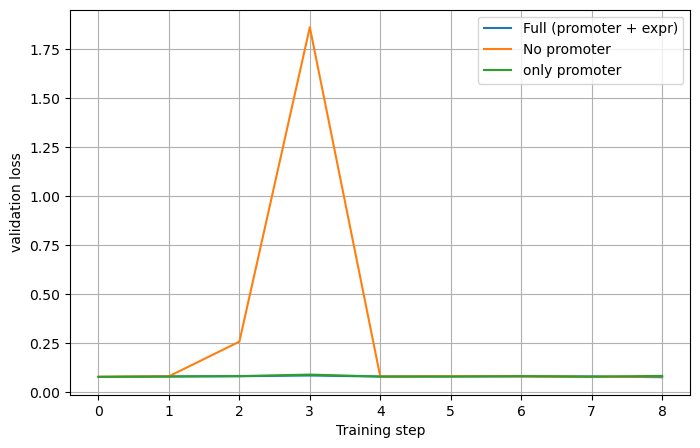

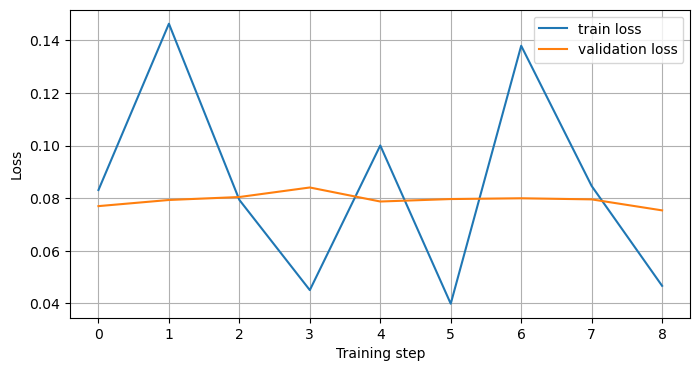

In [6]:
plt.figure(figsize=(8, 5))
validation_steps = list(range(len(validation_loss)))
# validation_loss_nop = validation_loss_nop[1:]
# validation_loss_ponly = validation_loss_ponly[1:]
plt.plot(validation_steps, validation_loss, label="Full (promoter + expr)")
plt.plot(validation_steps, validation_loss_nop, label="No promoter")
plt.plot(validation_steps, validation_loss_ponly, label="only promoter")
plt.xlabel("Training step")
plt.ylabel("validation loss")
#plt.title("A/B probe loss during training")
plt.legend()
plt.grid(True)
plt.show()

#train_loss = train_loss[:-1]
#validation_loss = validation_loss[:-1]
validation_steps = list(range(len(validation_loss)))
plt.figure(figsize=(8, 4))
plt.plot(validation_steps, train_loss, label="train loss")
plt.plot(validation_steps, validation_loss, label="validation loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
a=[1,2,3]
a[:-1]